In [3]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import train_test_val_split, evaluate_finetuned_model, get_pretrained_model_url

def plot_predicted_vs_true(y_true, y_pred, ax, title):
    ax.scatter(y_true, y_pred)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("True Yield kg/H")
    ax.set_ylabel("Predicted Yield kg/H")
    ax.set_title(title)

In [1]:
# Dataset Parameters
composite_window="month"
unique_id_column="Field_ID"
old_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_05112025/polygons/{composite_window}/"
data_2023_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_24022026/polygons/{composite_window}/"
new_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_04022026/polygons/{composite_window}/"

In [2]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_2023_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(new_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2025-07-01", "2025-11-30"],
)


NameError: name 'load_dataset' is not defined

#### Data investigation

In [33]:
# Print min and max of yield distribution for each year
th = 6000
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] < th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [34]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())

In [35]:
import matplotlib.pyplot as plt

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        axes[0, 2].hist(data[target_column].dropna(), alpha=0.7, bins=20, color=color, label=label)
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Remove the empty subplot
    axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

2026-02-23 14:25:49.967 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:397 - Training set size: 122
2026-02-23 14:25:49.969 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:398 - Validation set size: 20
2026-02-23 14:25:49.970 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:399 - Test set size: 20


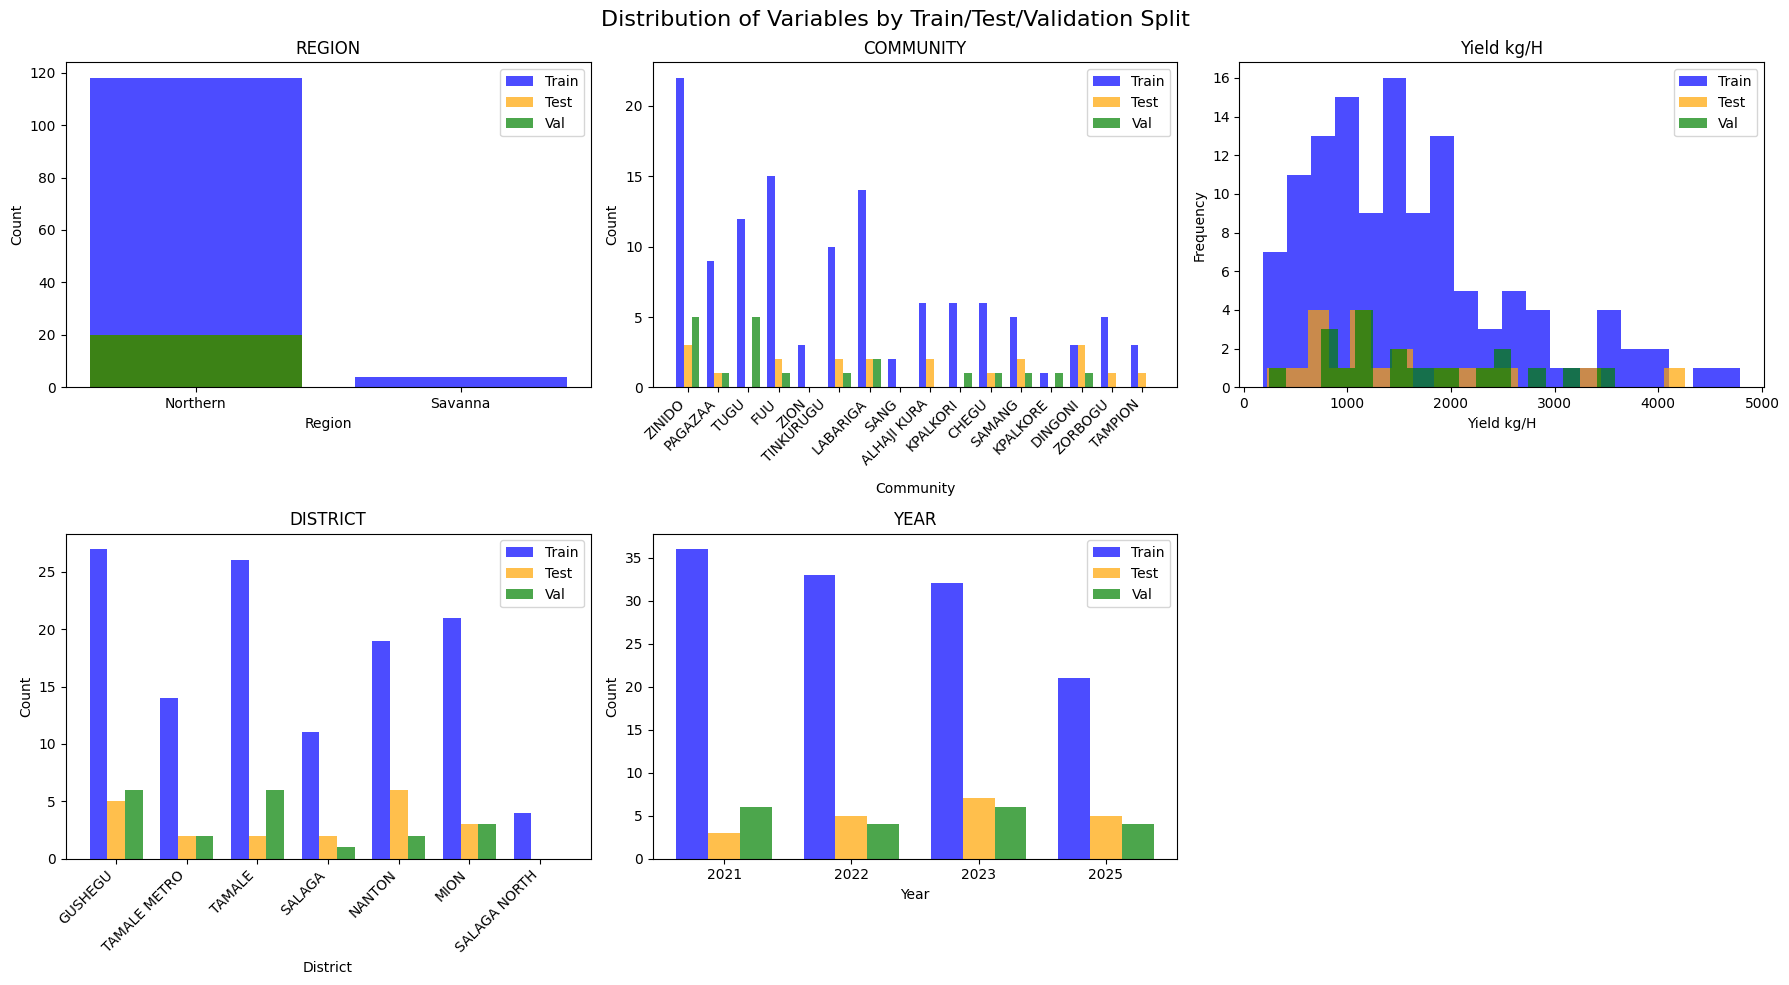

In [36]:
train_df, test_df, val_df = train_test_val_split(
    extractions,
    uniform_sample_by=target_column,
    sampling_frac=0.75,
    nmin_per_class=1, # do not change this parameter
)
plot_distribution(train_df, test_df, val_df, target_column)

#### Experiments on original data

##### Random Forest

In [37]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [9]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [38]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

R2_score on Train: 0.8441731205085414
R2_score on Val: -0.36393008141762584
R2_score on Test: 0.2604188792256723


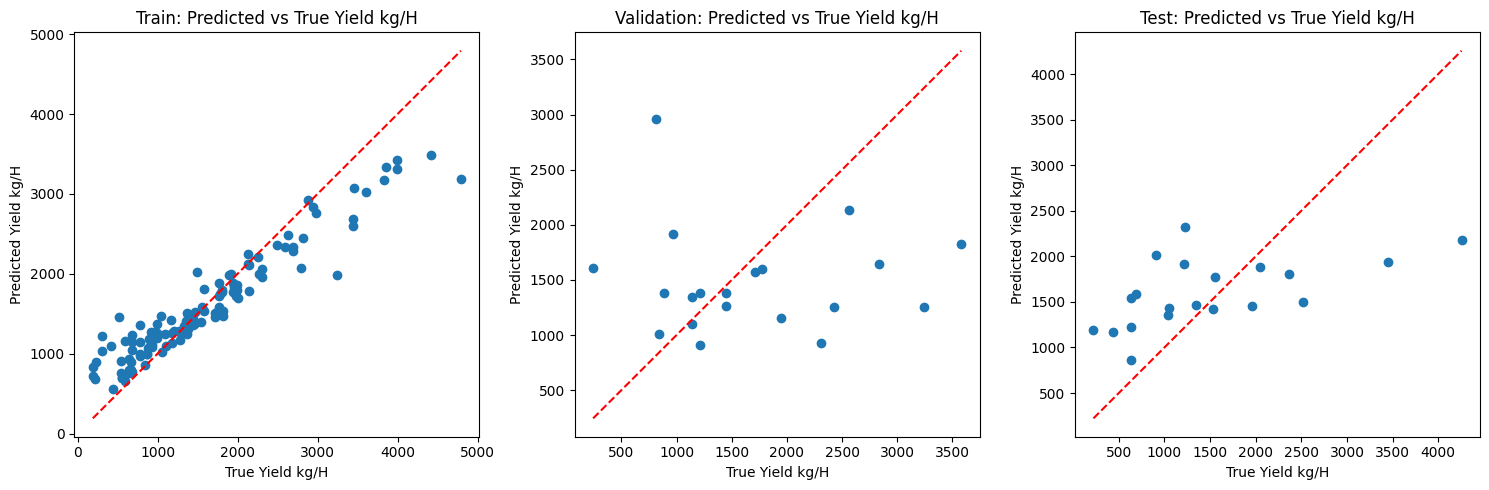

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ))
])

rf_pipe.fit(X_train, y_train)
print("R2_score on Train:", rf_pipe.score(X_train, y_train))
print("R2_score on Val:", rf_pipe.score(X_val, y_val))
print("R2_score on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Catboost 

0:	learn: 972.6589256	total: 50ms	remaining: 25s
499:	learn: 363.9373794	total: 1.14s	remaining: 0us
R2_score on Train: 0.8607481931986983
R2_score on Val: -0.2468661404202417
R2_score on Test: 0.14661186895191292


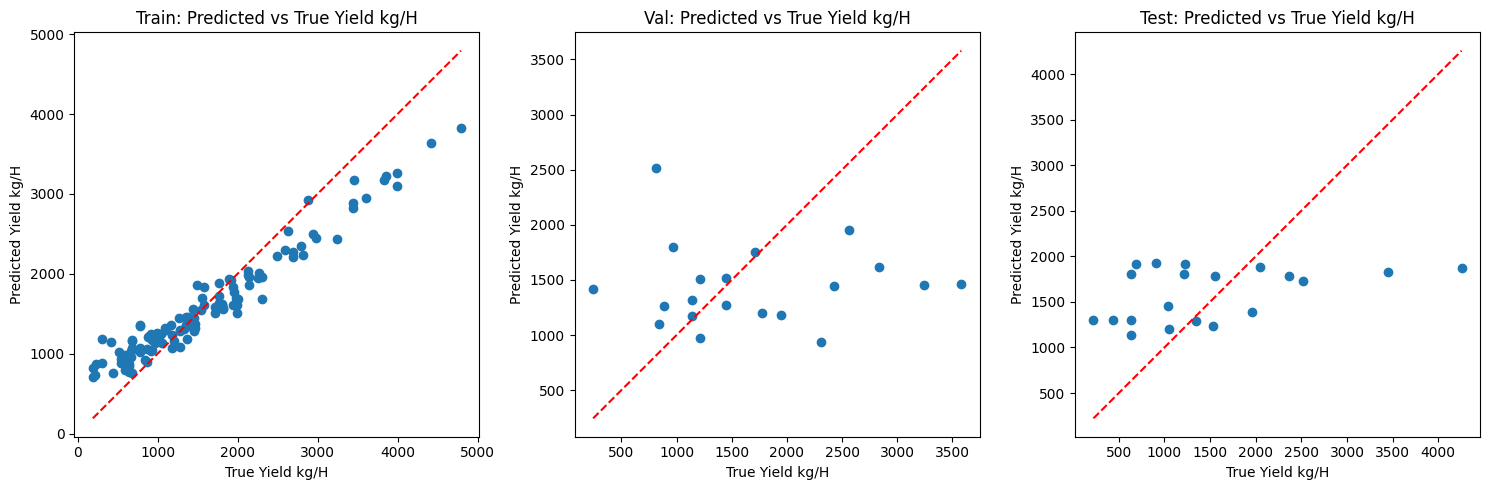

In [12]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose = 500
)

cat_reg.fit(X_train, y_train,
)

print("R2_score on Train:", cat_reg.score(X_train, y_train))
print("R2_score on Val:", cat_reg.score(X_val, y_val))
print("R2_score on Test:", cat_reg.score(X_test, y_test))

preds_train = cat_reg.predict(X_train) 
preds_val = cat_reg.predict(X_val)
preds_test = cat_reg.predict(X_test)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Val: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

##### Presto

In [39]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [40]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [41]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [16]:
loss_fn = nn.MSELoss()
# pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except Exception:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-23 11:22:33.067 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize
2026-02-23 11:22:33.072 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-23 11:22:33.072 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-23 11:22:33.073 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-23 11:22:33.073 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-23 11:22:33.073 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-23 11:22:33.073 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-23 11:22:33.074 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_p

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-23 11:22:33.245 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 2.3732 | Val Loss: 1.8434 | Best Loss: 1.8434 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-02-23 11:22:57.348 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 143/200: Epoch 143/200 | Train Loss: 0.9345 | Val Loss: 0.8267 | Best Loss: 0.8190 (no improvement for 28 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-23 11:22:57.769 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 144/200: Epoch 144/200 | Train Loss: 0.9348 | Val Loss: 0.8285 | Best Loss: 0.8190 (no improvement for 29 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-02-23 11:22:57.931 | INFO     | prometheo.finetune:_train_loop:161 - Early stopping!
2026-02-23 11:22:58.007 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [ ]:
# model = PretrainedPrestoWrapper(
#         num_outputs=num_outputs,
#         regression=True,
#     )
# finetuned_model = load_presto_weights(model, models_dir / experiment_name / f"{experiment_name}.pt", strict=False)

2026-02-23 14:29:01.674 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-23 14:29:01.821 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-23 14:29:01.851 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 0.856, 'MSE': 918534.3125, 'R2_score': 0.0343, 'RMSE': 958.402}
{'MAPE': 0.7234, 'MSE': 785413.875, 'R2_score': -0.051, 'RMSE': 886.2358}
{'MAPE': 1.0611, 'MSE': 1083479.0, 'R2_score': -0.068, 'RMSE': 1040.903}


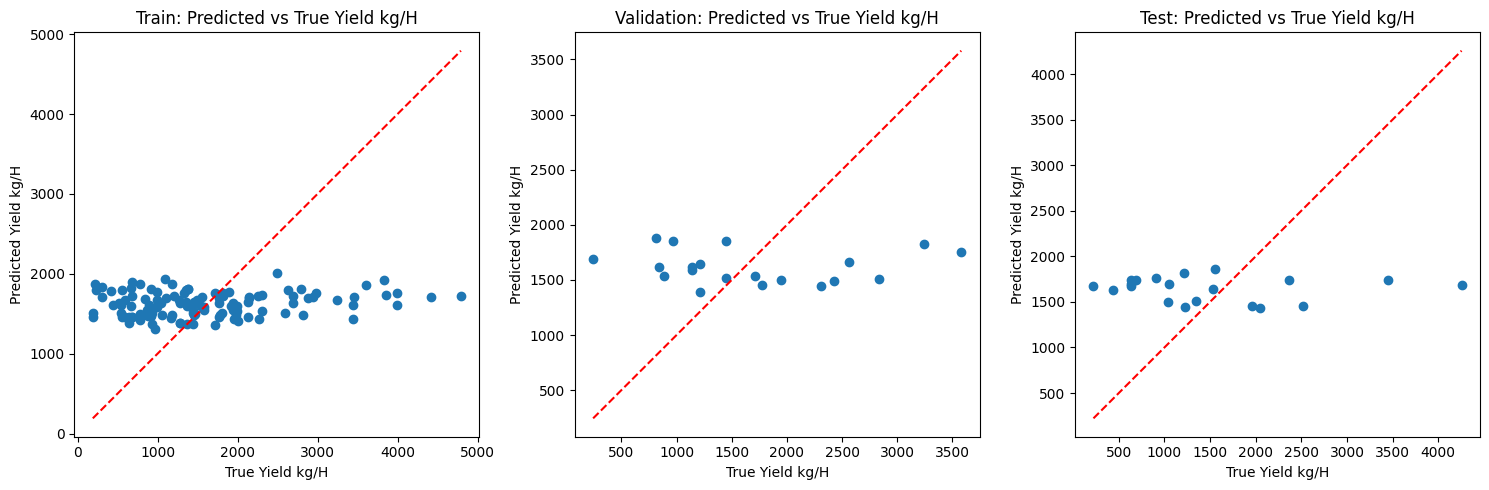

In [44]:
# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(train_targets, train_preds, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(val_targets, val_preds, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(targets, preds, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto + Catboost 

0:	learn: 0.9938103	total: 6.1ms	remaining: 3.04s
499:	learn: 0.4406348	total: 1.4s	remaining: 0us
R2_score on Train: 0.8042363226535031
R2_score on Val: -0.3033281559498149
R2_score on Test: 0.10332773984752741


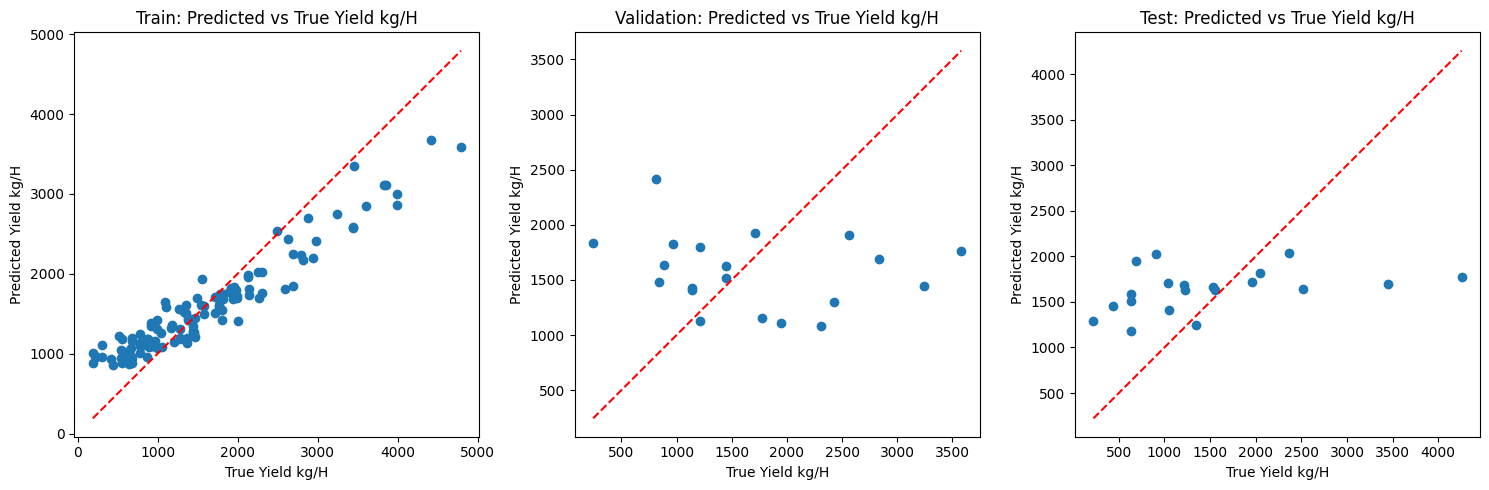

In [18]:
from scaleagdata_vito.presto.utils import get_encodings
model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
)
model = load_presto_weights(model, pretrained_model_path, strict=False)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)
print("R2_score on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("R2_score on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("R2_score on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_train = cat_enc_pipe.predict(all_encodings)
preds_val = cat_enc_pipe.predict(all_encodings_val)
preds_test = cat_enc_pipe.predict(all_encodings_test)

preds_train = train_ds.revert_to_original_units(preds_train)
preds_val = val_ds.revert_to_original_units(preds_val)
preds_test = test_ds.revert_to_original_units(preds_test)
all_targets = train_ds.revert_to_original_units(all_targets)
all_targets_val = val_ds.revert_to_original_units(all_targets_val)
all_targets_test = test_ds.revert_to_original_units(all_targets_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(all_targets, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

#### Experiments on augmented data

In [19]:
# strategy to get month array
import numpy as np 

def add_band_noise(df: pd.DataFrame, cols, sigma, per_row_bias=0.0, clip=None, rng=None):
    """
    Add Gaussian noise to selected columns.
    - sigma: float, or dict[col]->sigma
    - per_row_bias: add a constant bias per row (Gaussian with std=per_row_bias) across these cols
    - clip: tuple(min,max) or None
    """

    rng = np.random.default_rng() if rng is None else rng
    out = df.copy()

    X = out[cols].to_numpy(dtype=float)
    noise = rng.normal(0.0, 1.0, size=X.shape)

    if isinstance(sigma, dict):
        sig = np.array([sigma.get(c, 0.0) for c in cols], dtype=float)[None, :]
        Xn = X + noise * sig
    else:
        Xn = X + noise * float(sigma)

    if per_row_bias and per_row_bias > 0:
        bias = rng.normal(0.0, per_row_bias, size=(X.shape[0], 1))
        Xn = Xn + bias

    # preserve NaNs: adding noise would keep NaNs as NaN in numpy, but be explicit
    Xn[np.isnan(X)] = np.nan

    if clip is not None:
        Xn = np.clip(Xn, clip[0], clip[1])

    out[cols] = Xn
    return out

s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]

noise_variants = 4
train_nans = train_df.replace(65535, np.nan)
X_parts = [train_nans]
for k in range(noise_variants):
    Xk = train_nans.copy()
    rng = np.random.default_rng(42 + k)  # Different seed for each variant
    if s2_cols:
        Xk = add_band_noise(Xk, s2_cols, sigma=0.015, clip=(0.0, train_df[s2_cols].max().max()), rng=rng)
    if s1_cols:
        Xk = add_band_noise(Xk, s1_cols, sigma=0.4, per_row_bias=0.2, rng=rng)
    if meteo_cols:
        # conservative generic noise (you can refine per-variable by passing a sigma dict)
        Xk = add_band_noise(Xk, meteo_cols, sigma=0.02 * np.nanstd(train_nans[meteo_cols].to_numpy(dtype=float), axis=0, keepdims=True).mean(),
                        rng=rng)
    Xk['sample_id'] = Xk['sample_id'] + f"_AUG{k}"
    X_parts.append(Xk)

train_df_augmented = pd.concat(X_parts, ignore_index=True)
train_df_augmented.replace(np.nan, 65535, inplace=True)

print(f"Original train size: {len(train_df)}, Augmented train size: {len(train_df_augmented)}")
    

Original train size: 122, Augmented train size: 610


##### Random Forest

In [20]:
X_train_augmented, y_train_augmented = train_df_augmented[feature_columns], train_df_augmented[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [21]:
import numpy as np 

X_train_augmented = X_train_augmented.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

R2_score on Train: 0.9980249701379693
R2_score on Val: -0.435063635760951
R2_score on Test: 0.04376836219375713


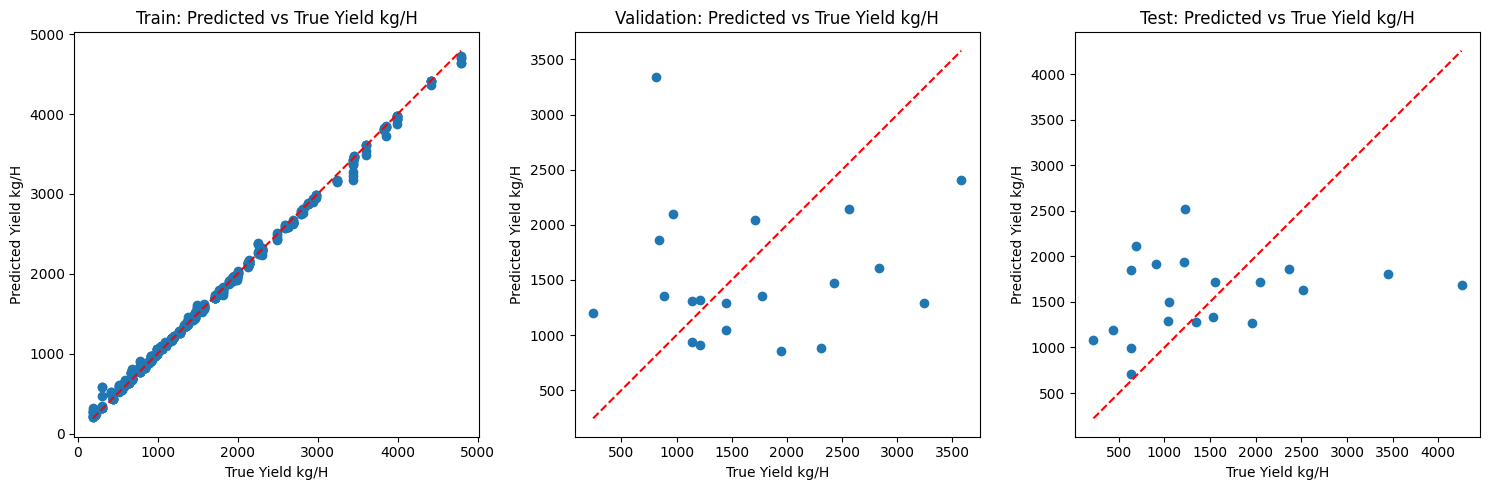

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ))
])

rf_pipe.fit(X_train_augmented, y_train_augmented)
print("R2_score on Train:", rf_pipe.score(X_train_augmented, y_train_augmented))
print("R2_score on Val:", rf_pipe.score(X_val, y_val))
print("R2_score on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train_augmented)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train_augmented, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Catboost 

0:	learn: 969.9034162	total: 6.07ms	remaining: 3.03s
499:	learn: 181.8062649	total: 1.58s	remaining: 0us
R2_score on Train: 0.9652491695281322
R2_score on Val: -0.23787641131884563
R2_score on Test: 0.04669116020674213


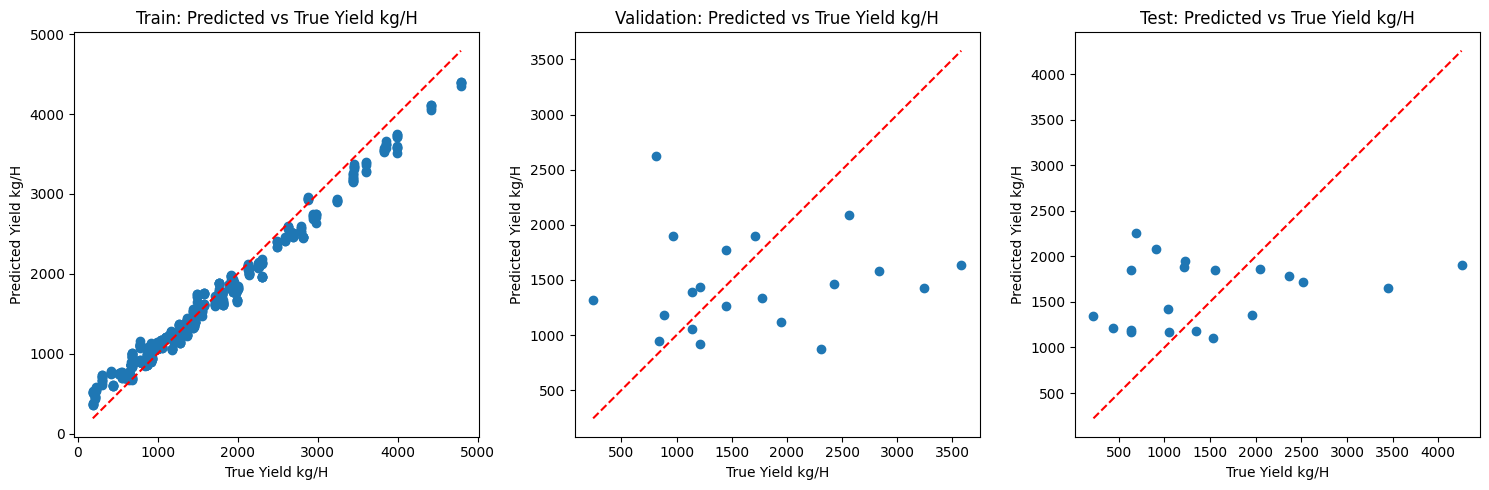

In [23]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
)


cat_reg.fit(X_train_augmented, y_train_augmented)

print("R2_score on Train:", cat_reg.score(X_train_augmented, y_train_augmented))
print("R2_score on Val:", cat_reg.score(X_val, y_val))
print("R2_score on Test:", cat_reg.score(X_test, y_test))

preds_train = cat_reg.predict(X_train_augmented) 
preds_val = cat_reg.predict(X_val)
preds_test = cat_reg.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train_augmented, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto

In [24]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [25]:
train_ds = ScaleAgDataset(
    dataframe=train_df_augmented,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [26]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-aug"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 200  # Keep reasonable number of epochs
patience = 30  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 200  # Keep early unfreezing

In [27]:
loss_fn = nn.MSELoss()
# pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except Exception:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-23 11:23:06.019 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize-aug
2026-02-23 11:23:06.021 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-23 11:23:06.022 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-23 11:23:06.022 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-23 11:23:06.023 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-23 11:23:06.023 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-23 11:23:06.024 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-23 11:23:06.024 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.

2026-02-23 11:23:06.038 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.blocks.1.norm2.bias
2026-02-23 11:23:06.038 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.blocks.1.mlp.fc1.weight
2026-02-23 11:23:06.039 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.blocks.1.mlp.fc1.bias
2026-02-23 11:23:06.039 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.blocks.1.mlp.fc2.weight
2026-02-23 11:23:06.039 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.blocks.1.mlp.fc2.bias
2026-02-23 11:23:06.040 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.norm.weight
2026-02-23 11:23:06.040 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.norm.bias
2026-02-23 11:23:06.041 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.month_embed.weight
2026-02-23 11:23:06.041 | INFO     | prometheo.finetune:_train_loop:80 

Finetuning:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-23 11:23:06.932 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/200: Epoch 1/200 | Train Loss: 1.5728 | Val Loss: 0.9290 | Best Loss: 0.9290 (improved)


...

2026-02-23 11:23:41.256 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 49/200: Epoch 49/200 | Train Loss: 0.9854 | Val Loss: 0.8365 | Best Loss: 0.8173 (no improvement for 28 epochs)


Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-23 11:23:42.100 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 50/200: Epoch 50/200 | Train Loss: 1.0000 | Val Loss: 0.8308 | Best Loss: 0.8173 (no improvement for 29 epochs)


Training:   0%|          | 0/20 [00:00<?, ?it/s]

2026-02-23 11:23:42.846 | INFO     | prometheo.finetune:_train_loop:161 - Early stopping!
2026-02-23 11:23:42.888 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


2026-02-23 11:23:42.929 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-23 11:23:43.808 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-23 11:23:43.833 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 0.8906, 'MSE': 944448.625, 'R2_score': 0.0071, 'RMSE': 971.8275}
{'MAPE': 0.7472, 'MSE': 783844.875, 'R2_score': -0.0489, 'RMSE': 885.3501}
{'MAPE': 1.1057, 'MSE': 1113670.25, 'R2_score': -0.0978, 'RMSE': 1055.3058}


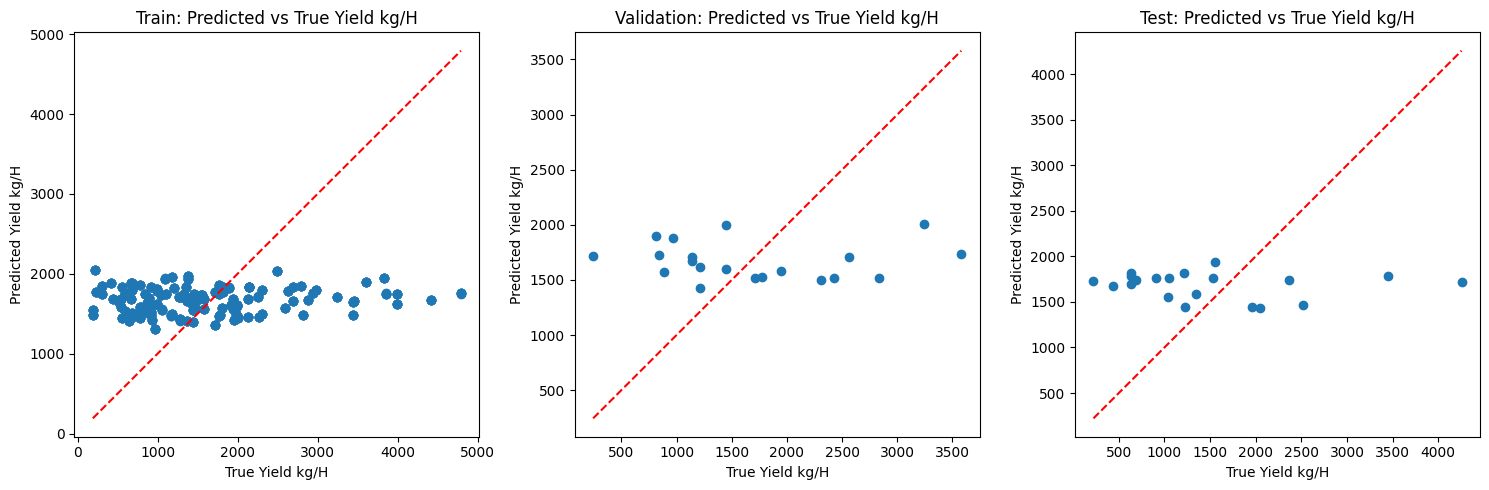

In [28]:
# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(train_targets, train_preds, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(val_targets, val_preds, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(targets, preds, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto + Catboost 

0:	learn: 0.9928390	total: 17.8ms	remaining: 8.87s
499:	learn: 0.2374012	total: 3.52s	remaining: 0us
R2_score on Train: 0.9431748905259184
R2_score on Val: -0.34066251848988416
R2_score on Test: 0.016499448643144454


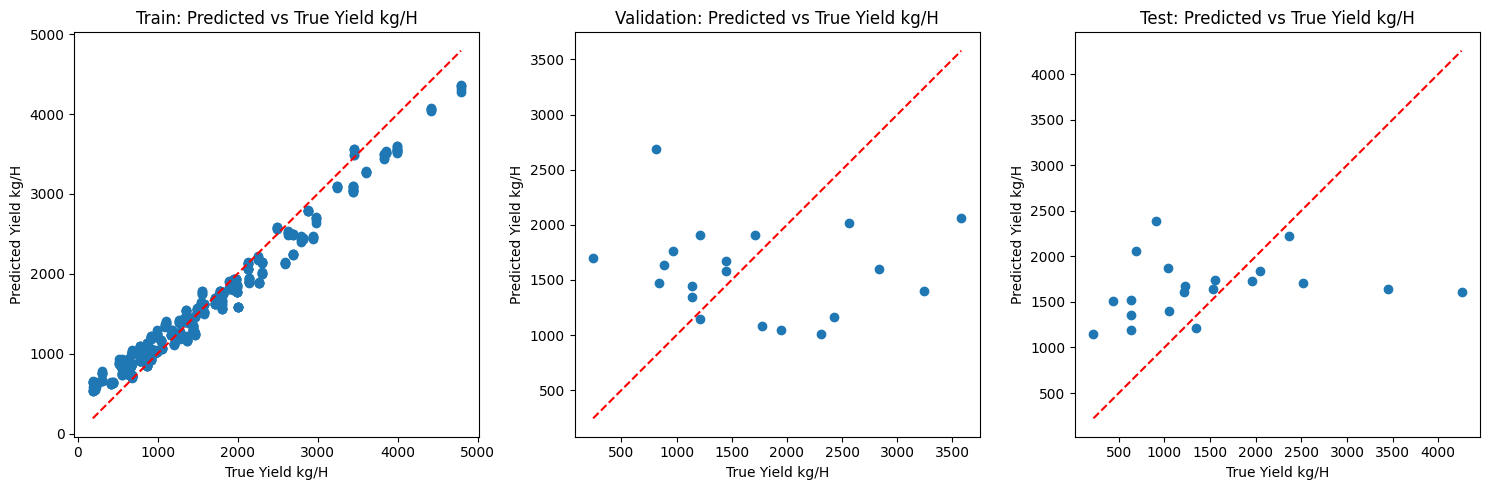

In [29]:
from scaleagdata_vito.presto.utils import get_encodings
model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
)
model = load_presto_weights(model, pretrained_model_path, strict=False)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)
print("R2_score on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("R2_score on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("R2_score on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_train = cat_enc_pipe.predict(all_encodings)
preds_val = cat_enc_pipe.predict(all_encodings_val)
preds_test = cat_enc_pipe.predict(all_encodings_test)

preds_train = train_ds.revert_to_original_units(preds_train)
preds_val = val_ds.revert_to_original_units(preds_val)
preds_test = test_ds.revert_to_original_units(preds_test)
all_targets = train_ds.revert_to_original_units(all_targets)
all_targets_val = val_ds.revert_to_original_units(all_targets_val)
all_targets_test = test_ds.revert_to_original_units(all_targets_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(all_targets, preds_train, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_val, preds_val, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_test, preds_test, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()